# Критерий Колмогорова 

Статья: https://github.com/avito-tech/applied_statistics/blob/main/Kolmogorov.ipynb

Идея: проверяем гипотезу, что наша выборка из какого-то распределения c известными параметрами

$H_0: F_0 = F$      
$H_1: F_0 \neq F$

Статистика:
$$D_n = \sup_{x \in \mathbb{R}} |\widehat{F}_n(x) - F_0(x)|$$
При $H_0$: $D_n \xrightarrow{p} 0, \sqrt{n}D_n \xrightarrow{d} \phi$, где $\phi$ - распределение Колмогорова

**Важная мысль**

В общем случае, если вы придумали критерий, и он дает FPR равный 0, значит это плохой критерий! Почему? Потому что он будет менее мощным чем другой критерий с уровнем значимости 5%!

**А что если мы не знаем параметров распределения F?**

Для нормального распределения можем использовать критерий Колмогорова Смирнова с поправкой Лиллиефорса или тест Шапиро Уилка 

Суть их в том, что придумывается статистика, много раз сэмплируются выборки по Монте-Карло, смотрится распределения этой статистики, и считаются критические значения

**Как визуализировать, что распределение есть нормальное? QQ-Plot** 

Если одно распределение можно получить из другого линейным преобразованием, то

$$\frac{Q_b - Q_a}{Q^{'}_b - Q^{'}_a} = \frac{\sigma}{\sigma^{'}} = const$$

Для нормальных распределений это верно 

Поэтому можно по одной оси отложить квантили одного распределения, по другой - другого, и посмотреть, насколько QQ линия похожа на прямую

In [48]:
import numpy as np 
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
import random

from tqdm import tqdm

from statsmodels.graphics.gofplots import qqplot

plt.rcParams['figure.dpi'] = 150

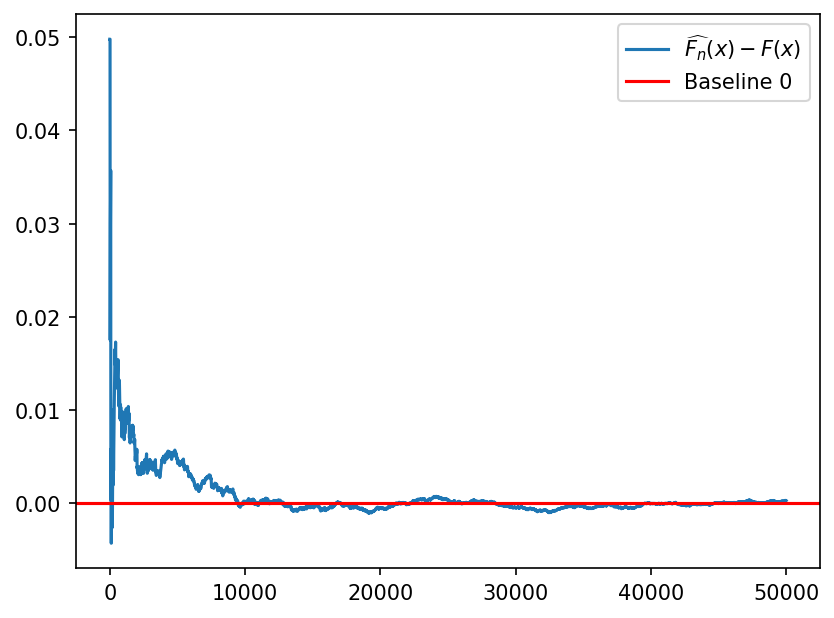

In [9]:
# Эмпирическая функция распределения
def empF(sample, x):
    return np.mean(sample <= x)

f = stats.expon()
x = 3
f_true = f.cdf(x)

N = 50000
ns = np.arange(1, N, 10)
X = f.rvs(N)

deltas = []

for n in ns:
    f_emp = empF(X[:n], x)
    deltas.append(f_emp - f_true)

deltas = np.array(deltas)

plt.plot(ns, deltas, label='$\\widehat{F_n}(x) - F({x})$')
plt.axhline(0, 0, N, color='red', label='Baseline 0')
plt.legend()


100%|██████████| 1000/1000 [00:00<00:00, 3264.37it/s]


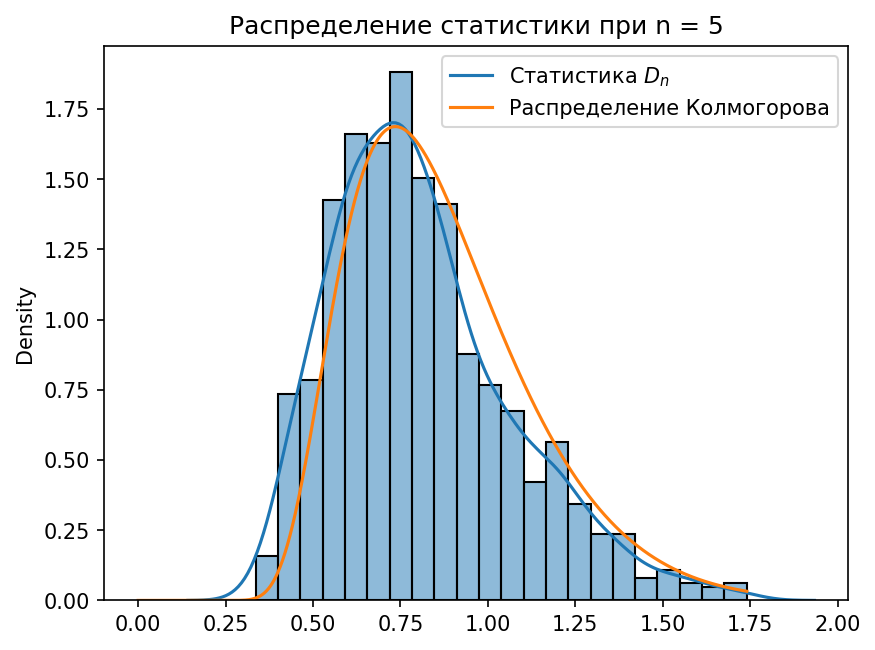

In [ ]:
# Посмотрим, как стастистика D_n приближает распределение Колмогорова

def get_D_statistic(sample, cdf_func):
    sample = np.sort(sample)
    F_x_n = np.array([empF(sample, x) for x in sample]) # Emperical Distribution function
    F_x_n_shifted = np.concatenate([[0], F_x_n[:-1]]) # shift to the the difference
    F_x = cdf_func(sample)

    left_interval_max = np.max(np.abs(F_x - F_x_n))
    right_interval_max = np.max(np.abs(F_x - F_x_n_shifted))
    return np.sqrt(len(sample)) * max(left_interval_max, right_interval_max)

# Sample size
sample_size = 5

statistics = []

# Generate the sample 1000 times
n_iter = 1000
for _ in tqdm(range(n_iter)):
    X = stats.expon().rvs(sample_size)
    d = get_D_statistic(X, stats.expon().cdf)
    statistics.append(d)

statistics = np.array(statistics)

sns.histplot(statistics, alpha=0.5, stat='density')
sns.kdeplot(statistics, label='Статистика $D_n$')
x = np.linspace(0, statistics.max(), 1000)
plt.plot(x, stats.kstwobign.pdf(x), label='Распределение Колмогорова')
plt.title(f"Распределение статистики при n = {sample_size}")
plt.legend()
plt.show()

In [38]:
# Протестируем критерий с помощью метода Монте-Карло

alpha = 0.05

dist = stats.norm()
sample_size = 100

type_one = []

n_iter = 1000
for _ in range(n_iter):
    sample = dist.rvs(sample_size)

    d_n = get_D_statistic(sample, dist.cdf)

    pvalue = 1 - stats.kstwobign.cdf(d_n)

    type_one.append(pvalue <= alpha)

type_one = np.array(type_one)
print(f"Type I: {type_one.mean():.3f}")

Type I: 0.052


For n=30 and alpha=0.05:
The simulated Lilliefors Critical Value is: 0.8644
Kolmogorov-Smirnov Critical Value is: 1.3581


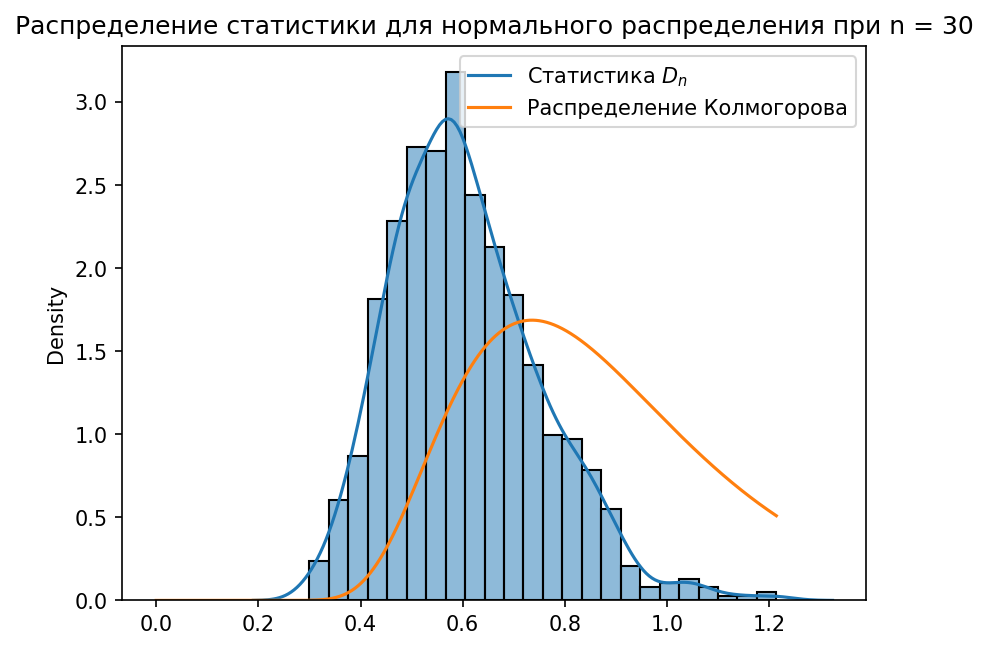

In [45]:
# Поправка Лиллиефорса (если мы не знаем параметры распределения)
# Смысл в том, что если мы оцениваем параметры нормального распределения по данным
# И потом их подставляем в критерий Колмогорова-Смирнова, то мы очень переобучаемся
# И на самом деле распределение немного другое
def get_lilliefors_critical_value(n_size, alpha=0.05, iterations=1000):
    ks_statistics = []

    for _ in range(iterations):
        # Generate a truly normal sample
        sample = np.random.normal(loc=0, scale=1, size=n_size)
        
        # Estimate parameters FROM THE SAMPLE (just like in real life)
        mu_hat = np.mean(sample)
        sigma_hat = np.std(sample, ddof=1)

        # Calculate D statistic
        d_n = get_D_statistic(sample, stats.norm(loc=mu_hat, scale=sigma_hat).cdf)
        
        ks_statistics.append(d_n)

    critical_value = np.quantile(ks_statistics, 1 - alpha)
    return critical_value, ks_statistics

# Example usage:
n = 30
alpha = 0.05
crit_val, ks_statistics = get_lilliefors_critical_value(n, alpha)

print(f"For n={n} and alpha={alpha}:")
print(f"The simulated Lilliefors Critical Value is: {crit_val:.4f}")
print(f"Kolmogorov-Smirnov Critical Value is: {stats.kstwobign().ppf(1 - alpha):.4f}")


ks_statistics = np.array(ks_statistics)

sns.histplot(ks_statistics, alpha=0.5, stat='density')
sns.kdeplot(ks_statistics, label='Статистика $D_n$')
x = np.linspace(0, ks_statistics.max(), 1000)
plt.plot(x, stats.kstwobign.pdf(x), label='Распределение Колмогорова')
plt.title(f"Распределение статистики для нормального распределения при n = {n}")
plt.legend()
plt.show()

/var/folders/0v/sg_b49cn52zb50mjq1g97xtc0000gn/T/ipykernel_35624/186473798.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.
  ax.plot(theoretical_quantiles, sample_quantiles, 'k.', linewidth=1.0, color = 'green')


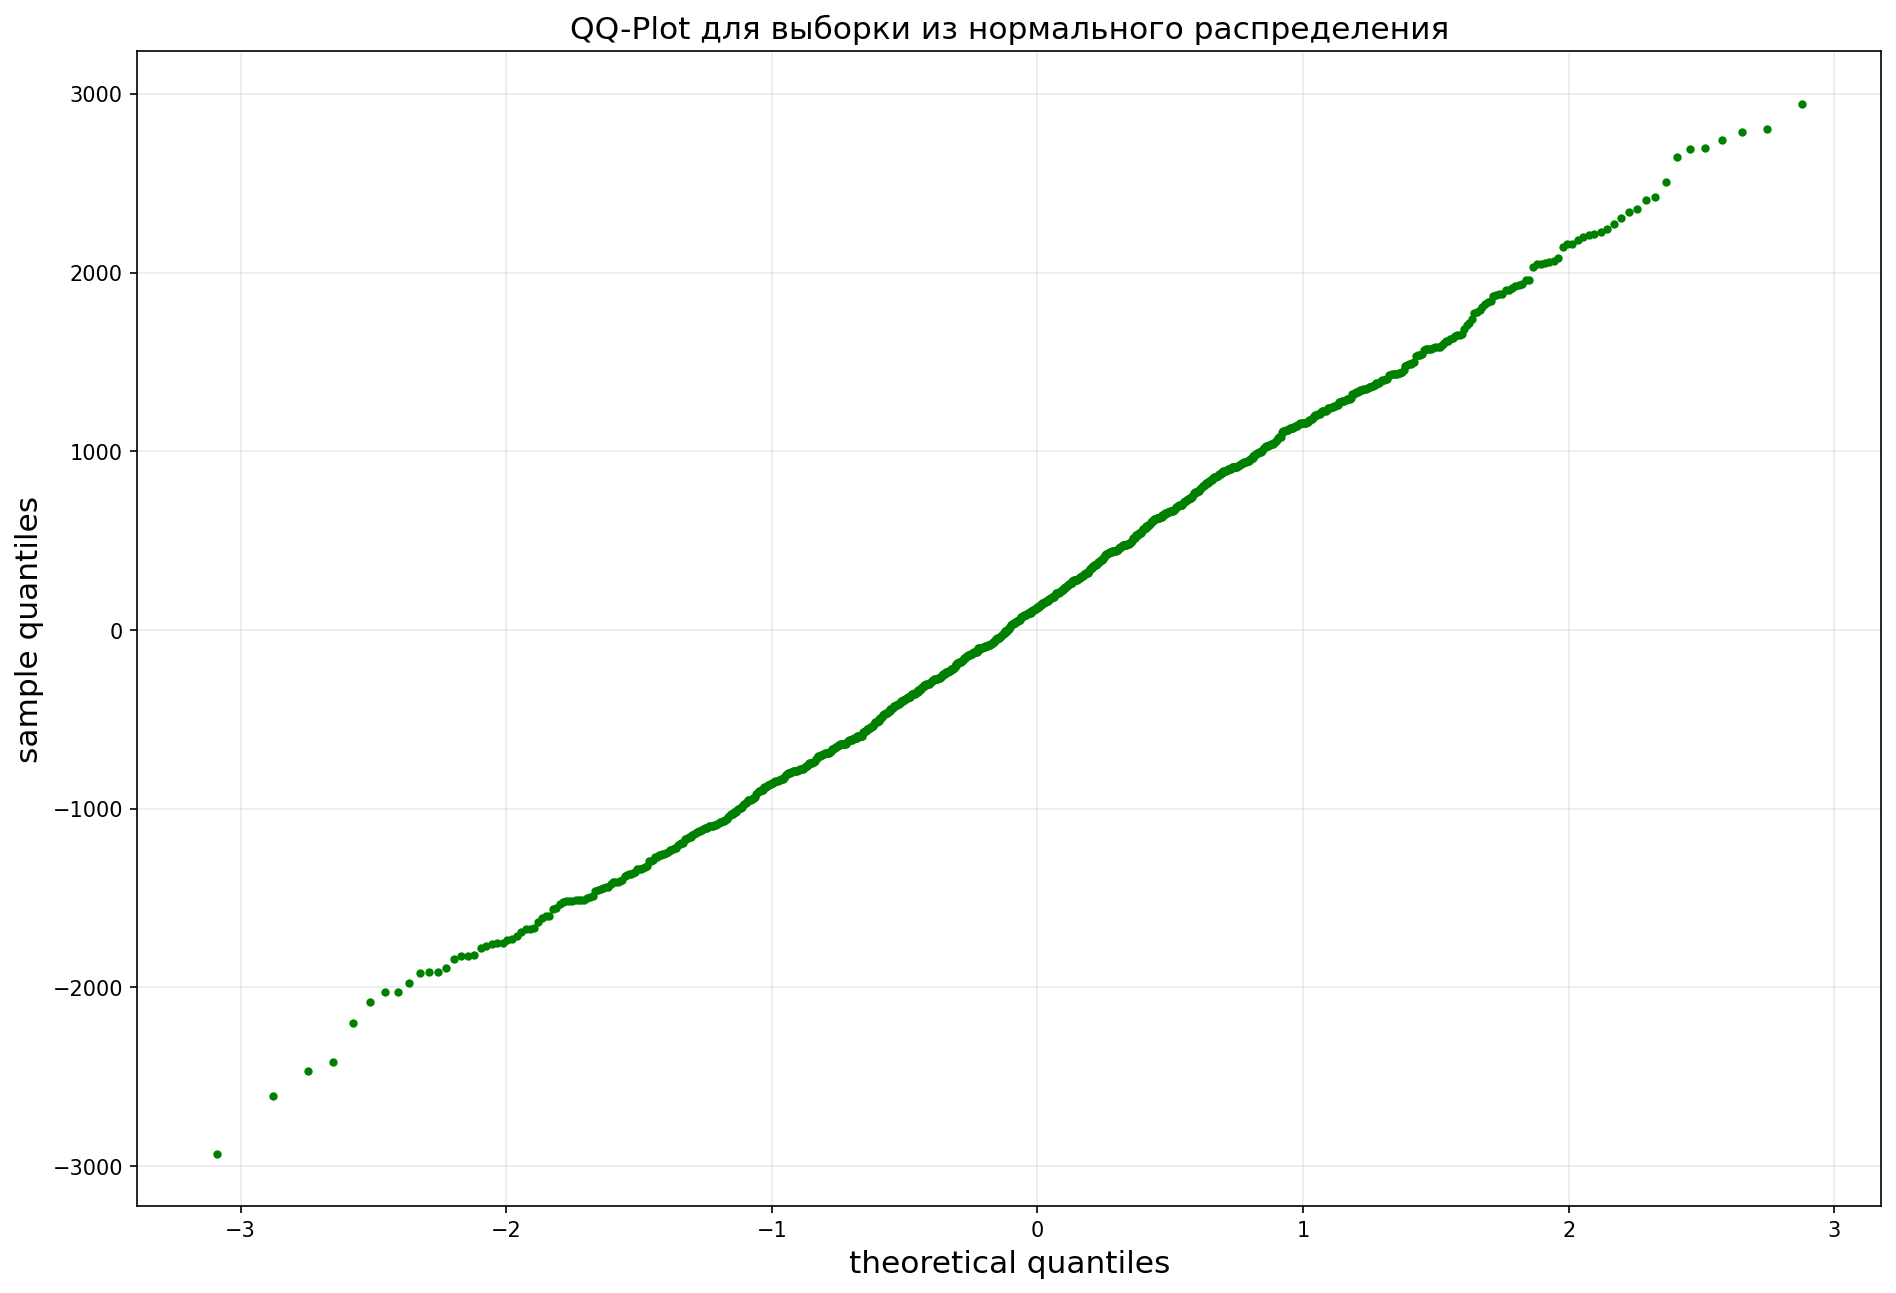

In [46]:
# Строим QQ-Plot

sample = stats.norm(loc=100, scale=1000).rvs(1000)

sample.sort()

sample_quantiles = sample[1:-1]
N = len(sample)

x = [i / N for i in range(1, N - 1)]
theoretical_quantiles = stats.norm().ppf(x)

# Визуализация
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1,1,1)

ax.plot(theoretical_quantiles, sample_quantiles, 'k.', linewidth=1.0, color = 'green')

ax.set_xlabel('theoretical quantiles', fontsize=15)
ax.set_ylabel('sample quantiles', fontsize=15)
ax.set_title('QQ-Plot для выборки из нормального распределения', fontsize=15)
plt.grid(linewidth=0.2)
plt.show()

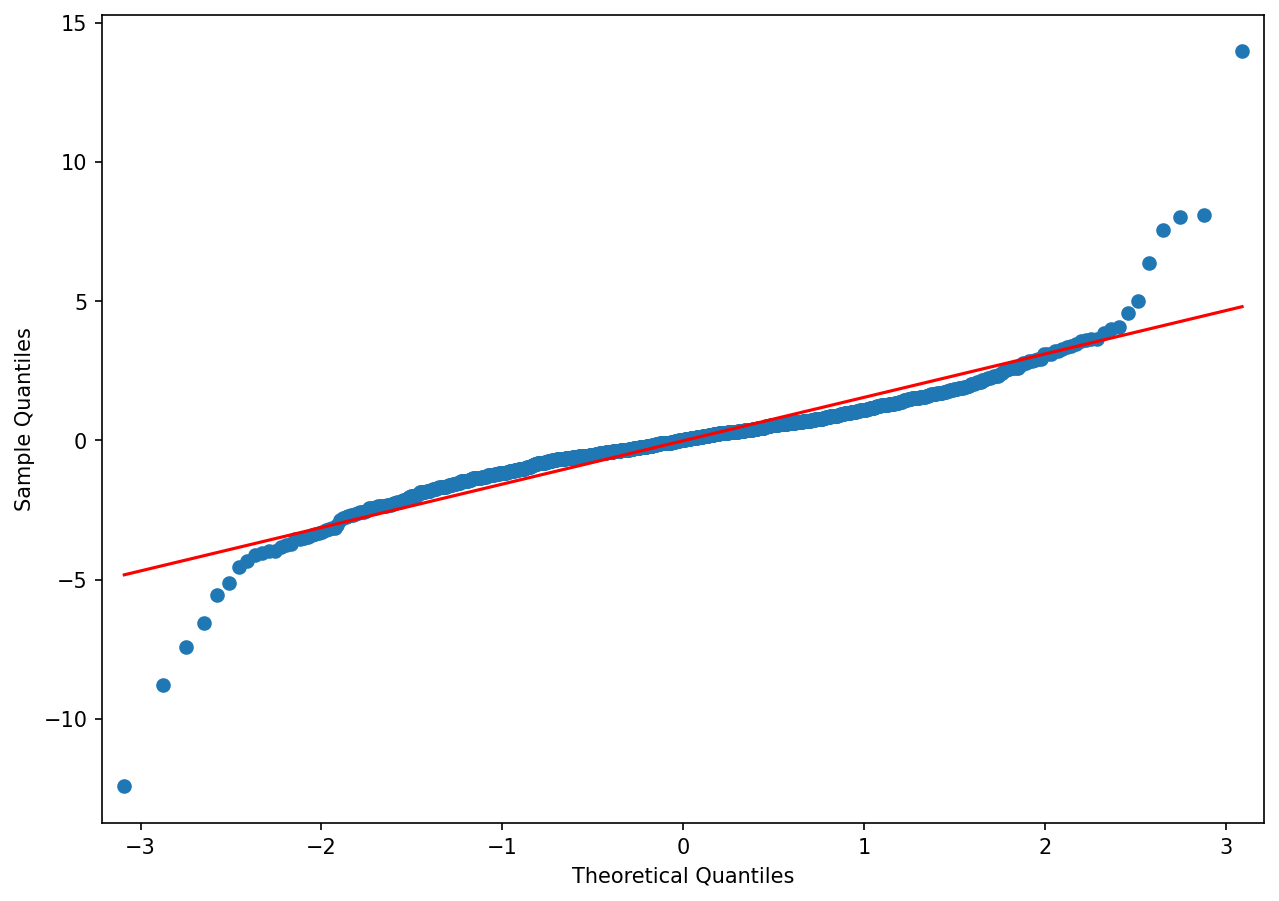

In [49]:
# Делаем обычный q plot

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(1,1,1)

qqplot(data=stats.t(df=3).rvs(1000), line='s', ax=ax)
plt.show()